# Project Objective: 
Goal: provide data-backed recommendations for improving profit, promotion effectiveness, inventory decisions, and store performance.

## Main problem:
Identify the main drivers of retail profitability and determine where the business is losing performance through weak products, ineffective promotions, high returns, or stock issues.

### The analysis should answer four core questions:

1. Which stores and product categories generate the most revenue and profit?
2. Do promotions actually improve sales enough to justify the discounts?
3. Which products or stores have unusually high return rates or weak margins?
4. Are there time-based patterns, such as weekday/weekend or monthly differences, that affect sales performance?

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import scipy.stats as st 
import matplotlib.pyplot as plt 


In [2]:
# Importing the data
tables = ['stores', 'products', 'daily_sales', 'promotions', 'returns']

for table in tables:
    globals() ['df_'+table] = pd.read_excel('retail_performance_project.xlsx', sheet_name=table)

# Task 1 — Dataset Inspection and Data Quality Diagnosis.

## Then answer these questions in your own words:

1. What does one row represent in each table?
2. Which tables are transactional/event tables, and which are lookup/reference tables?
3. Which columns should probably be datetime?
4. Which columns are IDs and should not be treated as ordinary numeric measurements?
5. Which columns contain missing values?
6. Which tables contain exact duplicate rows?
7. Do you notice any obviously impossible or suspicious numeric values?
8. Which tables will probably need to be merged later, and on which keys?

In [3]:
# Dataset Inspection and Data Quality Diagnosis.
df_stores.shape
df_stores.head()
df_stores.info()
df_stores.isna().sum()
df_stores.duplicated().sum()
print()
print("Table 'stores' have 8 rows and 8 columns.")
print("One row represent information about 1 store. That means the table is lookup/reference table.")
print("Column 'opened_date' is correctly store as datetime.")
print("store_id is ID and should not be treated as numerical measurements.")
print("In this table there is no missing values and duplicated values.")
print("There is no impossible or suspicous numeric values.")
print("This table would probably need to be merged later, on store_id as key.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   store_id       8 non-null      int64         
 1   store_name     8 non-null      object        
 2   city           8 non-null      object        
 3   region         8 non-null      object        
 4   store_type     8 non-null      object        
 5   opened_date    8 non-null      datetime64[ns]
 6   floor_area_m2  8 non-null      int64         
 7   manager        8 non-null      object        
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 644.0+ bytes

Table 'stores' have 8 rows and 8 columns.
One row represent information about 1 store. That means the table is lookup/reference table.
Column 'opened_date' is correctly store as datetime.
store_id is ID and should not be treated as numerical measurements.
In this table there is no missing values and duplicated val

In [4]:
df_products.shape
df_products.head()
df_products.info()
df_products.isna().sum()
df_products.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   product_id      20 non-null     int64         
 1   product_name    20 non-null     object        
 2   category        20 non-null     object        
 3   supplier        20 non-null     object        
 4   unit_cost_gbp   20 non-null     float64       
 5   list_price_gbp  20 non-null     float64       
 6   launch_date     20 non-null     datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 1.2+ KB


np.int64(0)

In [5]:
print("Table products have 20 rows and 7 columns.")
print("One table row represent information about one product. This table is lookup/reference table.")
print("launch_date columns is correctly store as datetime.")
print("product_id is ID and should not be treated as numeric measurement.")
print("There is no missing values and duplicated values.")
print("At first glance there is no suspicious numeric values and obviasly impossible.")
print("The table may be merged later on product_id as key.")

Table products have 20 rows and 7 columns.
One table row represent information about one product. This table is lookup/reference table.
launch_date columns is correctly store as datetime.
product_id is ID and should not be treated as numeric measurement.
There is no missing values and duplicated values.
At first glance there is no suspicious numeric values and obviasly impossible.
The table may be merged later on product_id as key.


In [6]:
df_daily_sales.shape
df_daily_sales.head()
df_daily_sales.isna().sum()
df_daily_sales.duplicated().sum()
df_daily_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7243 entries, 0 to 7242
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               7243 non-null   datetime64[ns]
 1   store_id           7243 non-null   int64         
 2   product_id         7243 non-null   int64         
 3   units_sold         7243 non-null   int64         
 4   gross_sales_gbp    7243 non-null   float64       
 5   discount_gbp       7243 non-null   float64       
 6   net_sales_gbp      7240 non-null   float64       
 7   cost_of_goods_gbp  7241 non-null   float64       
 8   stock_on_hand      7243 non-null   int64         
 9   customer_rating    7241 non-null   float64       
 10  promotion_id       1147 non-null   float64       
 11  notes              3168 non-null   object        
dtypes: datetime64[ns](1), float64(6), int64(4), object(1)
memory usage: 679.2+ KB


In [7]:
print("Table daily_sales have 7243 rows and 12 columns.")
print("One table row represent information about daily sales for one product in one store for one day. This table is transactional/event table.")
print("date column is correctly store as datetime.")
print("store_id, product_id and promotion_id are ID's and should not be treated as numeric measurements.")
print("Miising values: \nnet_sales_gbp: 3,\ncost_of_goods_gbp: 2,\ncustomer_rating: 2,\npromotion_id: 6096,\nnotes: 4075.\nTotal missing values are 10178.")
print("There is 3 duplicated rows.")
print("At first glance, stock on hand has value -5, customer_rating 6.2 and negative net_sales_gbp -156.972 are suspicious values.")
print("The table may be merged later on product_id,store_id and promotion_id as keys.")

Table daily_sales have 7243 rows and 12 columns.
One table row represent information about daily sales for one product in one store for one day. This table is transactional/event table.
date column is correctly store as datetime.
store_id, product_id and promotion_id are ID's and should not be treated as numeric measurements.
Miising values: 
net_sales_gbp: 3,
cost_of_goods_gbp: 2,
customer_rating: 2,
promotion_id: 6096,
notes: 4075.
Total missing values are 10178.
There is 3 duplicated rows.
At first glance, stock on hand has value -5, customer_rating 6.2 and negative net_sales_gbp -156.972 are suspicious values.
The table may be merged later on product_id,store_id and promotion_id as keys.


In [8]:
df_daily_sales.describe()

,date,store_id,product_id,units_sold,gross_sales_gbp,discount_gbp,net_sales_gbp,cost_of_goods_gbp,stock_on_hand,customer_rating,promotion_id
count,7243,7243.000000,7243.000000,7243.000000,7243.000000,7243.000000,7240.000000,7241.000000,7243.000000,7241.000000,1147.000000
mean,2026-03-31 23:17:27.245616640,204.499931,1010.390032,4.442634,394.799277,11.784134,382.839377,224.998502,18.345713,4.142922,4.547515
min,2026-01-01 00:00:00,201.000000,1001.000000,0.000000,0.000000,0.000000,-156.972000,0.000000,-5.000000,2.600000,1.000000
25%,2026-02-15 00:00:00,202.500000,1005.000000,3.000000,215.010000,0.000000,198.600000,119.460000,14.000000,3.900000,2.000000
50%,2026-04-01 00:00:00,204.000000,1010.000000,4.000000,344.440000,0.000000,335.190000,209.190000,18.000000,4.100000,5.000000
75%,2026-05-16 00:00:00,206.500000,1015.000000,6.000000,540.350000,0.000000,530.640000,314.550000,23.000000,4.400000,6.500000
max,2026-06-30 00:00:00,208.000000,1020.000000,14.000000,1591.920000,941.832000,1562.500000,836.760000,47.000000,6.200000,8.000000
std,NaN,2.291717,5.768659,2.132614,253.502052,33.723461,243.326540,139.929659,7.123892,0.434204,2.317352


In [9]:
df_promotions.shape
df_promotions.head()
df_promotions.isna().sum()
df_promotions.duplicated().sum()
df_promotions.info()
df_promotions.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   promotion_id    8 non-null      int64 
 1   promotion_name  8 non-null      object
 2   start_date      8 non-null      object
 3   end_date        8 non-null      object
 4   discount_pct    8 non-null      int64 
 5   category        8 non-null      object
 6   channel         8 non-null      object
dtypes: int64(2), object(5)
memory usage: 580.0+ bytes


,promotion_id,discount_pct
count,8.00000,8.000000
mean,4.50000,14.625000
std,2.44949,3.292307
min,1.00000,10.000000
25%,2.75000,12.000000
50%,4.50000,15.000000
75%,6.25000,15.750000
max,8.00000,20.000000


In [10]:
print("The table promotions has 8 rows and 7 columns.")
print("One table row represent information about one promotion campaign. This table is lookup/reference table describing promotion events.")
print("columns start_date and end_date should be store as datetime type.")
print("promotion_id is ID and should not be treated as numerical measurement.")
print("No missing values and duplicated values.")
print("At first glance there is no suspicious numeric values and obviasly impossible.")
print("The table may be merged later on promotion_id as key.")

The table promotions has 8 rows and 7 columns.
One table row represent information about one promotion campaign. This table is lookup/reference table describing promotion events.
columns start_date and end_date should be store as datetime type.
promotion_id is ID and should not be treated as numerical measurement.
No missing values and duplicated values.
At first glance there is no suspicious numeric values and obviasly impossible.
The table may be merged later on promotion_id as key.


In [11]:
df_returns.shape
df_returns.head()
df_returns.info()
df_returns.isna().sum()
df_returns.duplicated().sum()
df_returns.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261 entries, 0 to 260
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   return_id       261 non-null    int64         
 1   return_date     261 non-null    datetime64[ns]
 2   store_id        261 non-null    int64         
 3   product_id      261 non-null    int64         
 4   units_returned  261 non-null    int64         
 5   refund_gbp      261 non-null    float64       
 6   reason          260 non-null    object        
 7   condition       261 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(2)
memory usage: 16.4+ KB


,return_id,return_date,store_id,product_id,units_returned,refund_gbp
count,261.000000,261,261.000000,261.000000,261.000000,261.000000
mean,130.210728,2026-03-31 05:03:26.896551680,204.475096,1010.398467,1.076628,83.282375
min,1.000000,2026-01-04 00:00:00,201.000000,1001.000000,1.000000,18.550000
25%,65.000000,2026-02-13 00:00:00,203.000000,1005.000000,1.000000,46.660000
50%,130.000000,2026-03-31 00:00:00,204.000000,1010.000000,1.000000,82.640000
75%,195.000000,2026-05-14 00:00:00,206.000000,1016.000000,1.000000,108.680000
max,260.000000,2026-06-27 00:00:00,208.000000,1020.000000,2.000000,251.680000
std,75.200333,NaN,2.309752,5.732015,0.266512,41.614818


In [12]:
print("The table returns has 261 rows and 8 columns.")
print("One table row represent information about return event for a product in a store on paricular date. This table is transaction/event table.")
print("columns return_date is correctly store as datetime type.")
print("return_id, store_id, product_id are identifiers and should not be treated as numerical measurements.")
print("Missing values:\nreason: 1\nThere is one duplicated values.")
print("At first glance there is no suspicious numeric values and obviasly impossible.")
print("The table may be merged later with stores on store_id and products on  product_id as keys.")

The table returns has 261 rows and 8 columns.
One table row represent information about return event for a product in a store on paricular date. This table is transaction/event table.
columns return_date is correctly store as datetime type.
return_id, store_id, product_id are identifiers and should not be treated as numerical measurements.
Missing values:
reason: 1
There is one duplicated values.
At first glance there is no suspicious numeric values and obviasly impossible.
The table may be merged later with stores on store_id and products on  product_id as keys.


# Task 2 — Clean the Data

Now that you understand the structure, clean the tables before doing any analysis.

Focus first on df_daily_sales, because it contains most of the problems.

### Part A — Create a clean copy

Do not modify the original DataFrame.

### Part B — Remove exact duplicates

1. Count duplicates.
2. Remove them.
3. Check how many rows remain.

### Part C — Handle missing values

Inspect these columns:

- net_sales_gbp
- cost_of_goods_gbp
- customer_rating
- promotion_id
- notes

Do not automatically drop every row with a missing value.

Decide separately what to do with each column and explain your reasoning.

For example, think about:

- Is the column essential for financial analysis?
- Does a missing promotion_id necessarily mean bad data?
- Is notes important enough to drop rows because it is missing?

### Part D — Investigate suspicious values

Check the rows containing:

negative stock_on_hand

customer_rating > 5

negative net_sales_gbp

Do not fix them yet. First inspect the entire rows and determine what may have caused the problem.

### Part E — Convert promotion dates

In df_promotions, convert:

start_date
end_date

to datetime if needed.

### Part F — Returns table

For df_returns:

- remove the exact duplicate
- inspect the missing reason
- decide whether that row should be removed or whether the missing reason can remain

In [13]:
#Part A 
# make copy of df_daily_sales
df_sales_clean = df_daily_sales.copy()
#Part B 
#count the duplicated
duplicated = df_sales_clean.duplicated().sum()
df_sales_clean[df_sales_clean.duplicated(keep=False)]
#drop the duplicates
df_sales_clean.drop_duplicates(inplace=True)
df_sales_clean.shape
print(f"Duplicates are {duplicated}, after removing the remaining rows are {df_sales_clean.shape[0]}.")
#part C 
df_sales_clean[df_sales_clean.net_sales_gbp.isna()].shape[0]/df_sales_clean.shape[0]*100
df_sales_clean[df_sales_clean.cost_of_goods_gbp.isna()].shape[0]/df_sales_clean.shape[0]*100
df_sales_clean.customer_rating.isna().sum()/df_sales_clean.shape[0]*100
print("I can drop missing values in net_sales_gbp, cost_of_goods_gbp and customer_rating because their count is so small and it won't change the data significantly.\n\
Their part of total data is under 0.05%.")
df_sales_clean.dropna(subset=['net_sales_gbp','cost_of_goods_gbp', 'customer_rating'], inplace=True)
print('missing value for promotion_id is not bad data because it means there is no promotion in that record.')
print("Column 'notes' is not so import to drop the rows because there is a missing values.")
df_sales_clean[['net_sales_gbp','cost_of_goods_gbp', 'customer_rating']].isna().sum()

Duplicates are 3, after removing the remaining rows are 7240.
I can drop missing values in net_sales_gbp, cost_of_goods_gbp and customer_rating because their count is so small and it won't change the data significantly.
Their part of total data is under 0.05%.
missing value for promotion_id is not bad data because it means there is no promotion in that record.
Column 'notes' is not so import to drop the rows because there is a missing values.


net_sales_gbp        0
cost_of_goods_gbp    0
customer_rating      0
dtype: int64

In [14]:
#Part D 
df_sales_clean[df_sales_clean['stock_on_hand'] < 0]
print("I am not familiar with business logic and it may be correct record stock_on_hand smaller than 0 but I recommend to remove it or change to 0.")
# drop stock_on_hand under 0 
df_sales_clean.drop(df_sales_clean[df_sales_clean['stock_on_hand'] < 0].index, inplace=True)
df_sales_clean[df_sales_clean['stock_on_hand'] < 0]
# drop customer_rating greater than 5 
df_sales_clean[df_sales_clean['customer_rating'] > 5]
print("There is one record with customer_rating higher than 5 and I can drop it or change it to 5, because it is greater than 5.")
df_sales_clean = df_sales_clean[df_sales_clean['customer_rating'] <= 5]
df_sales_clean[df_sales_clean['customer_rating'] > 5]
#drop the negative net_sales 
df_sales_clean.loc[df_sales_clean['net_sales_gbp']<0, ['gross_sales_gbp','discount_gbp', 'net_sales_gbp']]
print("The discount is greater than gross_sales and that's why the net_sales_gbp is negative number. I can correct the discount but i am not acquainted with business logic enough to do this.My recomendation is to remove the row.")
df_sales_clean.drop(df_sales_clean[df_sales_clean['net_sales_gbp'] < 0].index, inplace=True)
df_sales_clean[df_sales_clean['net_sales_gbp'] < 0].shape[0]
print("Negative stock:", (df_sales_clean['stock_on_hand'] < 0).sum())
print("Rating above 5:", (df_sales_clean['customer_rating'] > 5).sum())
print("Negative net sales:", (df_sales_clean['net_sales_gbp'] < 0).sum())
print("Remaining rows:", df_sales_clean.shape[0])

I am not familiar with business logic and it may be correct record stock_on_hand smaller than 0 but I recommend to remove it or change to 0.
There is one record with customer_rating higher than 5 and I can drop it or change it to 5, because it is greater than 5.
The discount is greater than gross_sales and that's why the net_sales_gbp is negative number. I can correct the discount but i am not acquainted with business logic enough to do this.My recomendation is to remove the row.
Negative stock: 0
Rating above 5: 0
Negative net sales: 0
Remaining rows: 7230


In [15]:
# Part E 
# converting the start_date and end_date to datetime 
cols = ['start_date', 'end_date']
df_promotions[cols]=df_promotions[cols].apply(lambda col: pd.to_datetime(col, yearfirst=True)) 
df_promotions[cols].dtypes

start_date    datetime64[ns]
end_date      datetime64[ns]
dtype: object

In [16]:
# part F 
df_clean_returns = df_returns.copy()
# count  the duplicates
df_clean_returns.duplicated().sum()
df_clean_returns[df_clean_returns.duplicated(keep=False)]
# removing the duplicates
df_clean_returns.drop_duplicates(inplace=True)
df_clean_returns[df_clean_returns.duplicated(keep=False)]
#inspecting the missing values in reason columns 
df_clean_returns.isna().sum()
# I will fill missing value in reason with Unknown to keep other columns informations.
df_clean_returns.fillna('Unknown',inplace=True)
df_clean_returns[df_clean_returns['reason']=='Unknown']
#Final shape
df_clean_returns.shape

(260, 8)

# Task 3 — Feature Engineering and Profit Analysis

Now that the data is cleaned, the goal is to create useful business metrics from df_sales_clean.

Use only the cleaned sales table for this task.

### Part A — Create profit features

Create two new columns:

profit_gbp

profit_margin_pct

Think about how they should be calculated from the existing sales and cost columns.

Then answer:

1. What does profit_gbp represent?
2. What does profit_margin_pct represent?
3. Can profit be positive while profit margin is low? Explain.


### Part B — Create time features

From the date column, create:

month

month_name

day_of_week

is_weekend

For is_weekend, use a Boolean value:

True
False

Then check the new columns with:

df_sales_clean[['date', 'month', 'month_name', 'day_of_week', 'is_weekend']].head()

### Part C — Overall performance

Calculate:

- total net sales
- total cost of goods
- total profit
- average profit per row
- average profit margin

Then answer:

Is the business profitable overall in this dataset?

### Part D — Daily performance

Group by date and calculate:

- total net sales
- total profit
- total units sold

Find:

- highest-sales day
- highest-profit day
- lowest-profit day

In [17]:
# Part A 
df_sales_clean['profit_gbp']=df_sales_clean['net_sales_gbp'] - df_sales_clean['cost_of_goods_gbp']
df_sales_clean[df_sales_clean['net_sales_gbp'] == 0] 
df_sales_clean['profit_margin_pct'] = (df_sales_clean['profit_gbp']/df_sales_clean['net_sales_gbp'] * 100).round(2)
print('profit_gbp represent the revenue from a saling, the difference between net_sale and cost_of_goods.')
print('profit_margin_pct represent what percentage of net sales remain as profit.')
print("Yes a row can has a high profit in gbp but relatively low profit margin, if the net_sales is high.")

profit_gbp represent the revenue from a saling, the difference between net_sale and cost_of_goods.
profit_margin_pct represent what percentage of net sales remain as profit.
Yes a row can has a high profit in gbp but relatively low profit margin, if the net_sales is high.


In [18]:
zero_sales = df_sales_clean[df_sales_clean['net_sales_gbp'] == 0]

zero_sales[
    ['units_sold',
     'gross_sales_gbp',
     'discount_gbp',
     'net_sales_gbp',
     'cost_of_goods_gbp',
     'profit_gbp']
].describe()

,units_sold,gross_sales_gbp,discount_gbp,net_sales_gbp,cost_of_goods_gbp,profit_gbp
count,187.0,187.0,187.0,187.0,187.0,187.0
mean,0.0,0.0,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0,0.0


In [19]:
# part B 
df_sales_clean['month'] = df_sales_clean.date.dt.month
df_sales_clean['month_name'] = df_sales_clean.date.dt.month_name()
df_sales_clean['day_of_week'] = df_sales_clean.date.dt.day_name()
df_sales_clean['is_weekend'] = df_sales_clean.date.dt.day_of_week>4 
df_sales_clean[['month', 'month_name', 'day_of_week', 'is_weekend']]

,month,month_name,day_of_week,is_weekend
0,1,January,Thursday,False
1,1,January,Thursday,False
2,1,January,Thursday,False
3,1,January,Thursday,False
4,1,January,Thursday,False
...,...,...,...,...
7235,6,June,Tuesday,False
7236,6,June,Tuesday,False
7237,6,June,Tuesday,False
7238,6,June,Tuesday,False


In [20]:
# Part C 
total_net_sales = df_sales_clean['net_sales_gbp'].sum()
print(f"The total net sales is {total_net_sales} GBP.")
total_cost_of_goods = df_sales_clean.cost_of_goods_gbp.sum() 
print(f"The total cost of goods is {total_cost_of_goods} GBP.")
total_profit = df_sales_clean.profit_gbp.sum()
print(f"The total profit is {total_profit:.2f} GBP.")
average_profit = df_sales_clean.profit_gbp.mean()
print(f"The average profit is {average_profit:.2f} GBP.")
average_profit_margin = df_sales_clean.profit_margin_pct.mean()
print(f"The average profit margin is {average_profit_margin:.2f}%.")
print(f"Yes, the business is profitable overall in this dataset with total profit {total_profit:.2f} GBP.")

The total net sales is 2768678.02 GBP.
The total cost of goods is 1625938.32 GBP.
The total profit is 1142739.70 GBP.
The average profit is 158.06 GBP.
The average profit margin is 40.29%.
Yes, the business is profitable overall in this dataset with total profit 1142739.70 GBP.


In [21]:
# part D 
#total net sales by day 
total_net_sales_by_day = df_sales_clean.groupby('date')['net_sales_gbp'].sum()
#total profit by day 
total_profit_by_day = df_sales_clean.groupby('date')['profit_gbp'].sum()
#total units sold 
total_unit_sold_by_day = df_sales_clean.groupby('date')['units_sold'].sum()
highest_sales_day = total_net_sales_by_day.idxmax()
print(f"{highest_sales_day} is highest sales day.")
highest_profit_day = total_profit_by_day.idxmax()
print(f"{highest_profit_day} is the day with highest profit.")
print(f"{total_profit_by_day.idxmin()} is the day with lowest profit")

daily_summary=df_sales_clean.groupby('date').agg(
    total_sales = ('net_sales_gbp', 'sum'),
    total_profit = ('profit_gbp', 'sum'),
    total_sold_units = ('units_sold', 'sum')
)

2026-02-21 00:00:00 is highest sales day.
2026-02-08 00:00:00 is the day with highest profit.
2026-04-23 00:00:00 is the day with lowest profit


# Task 4 — Merge Sales with Store and Product Information

Now we want to move from row-level sales to meaningful business analysis.

### Part A — Merge lookup tables

Merge df_sales_clean with:

df_stores using store_id

df_products using product_id

Create one new DataFrame, for example:

df_sales_merged

Use a left join so you keep all cleaned sales rows.

After merging, check:

- shape before and after
- whether row count changed
- missing values in store_name
- missing values in product_name
- whether store_id and product_id are unique in their lookup tables

Also think about why validate='many_to_one' would be useful here.

### Part B — Store performance

Group by store_name and calculate:

- total net sales
- total profit
- average profit margin
- total units sold

Then identify:

1. store with highest total sales
2. store with highest total profit
3. store with highest average profit margin
4. store with highest units sold

### Part C — Category performance

Group by category and calculate the same metrics:

- total net sales
- total profit
- average profit margin
- total units sold

Then answer:

1. Which category generates the most revenue?
2. Which category generates the most profit?
3. Does the highest-revenue category also have the highest margin?

### Part D — Product performance

Group by product_name and calculate:

- total sales
- total profit
- units sold

Find:

- top 5 products by sales
- top 5 by profit
- bottom 5 by profit

In [22]:
# Part A 
df_sales_merged = pd.merge(left=df_sales_clean, left_on='store_id',right=df_stores, right_on='store_id',how='left',validate="many_to_one")
df_sales_merged = pd.merge(left=df_sales_merged,left_on='product_id', right=df_products, right_on='product_id', how='left',validate='many_to_one')
df_sales_clean.shape
df_sales_merged.shape
print("df_sales_clean has 7230 rows and 18 columns before merge and same count rows 7230 and 31 columns after the merges.")
df_sales_merged['store_name'].isna().sum()
df_sales_merged['product_name'].isna().sum()
print("In columns 'store_name' and ' product_name' has 0 missing values.")
df_stores.store_id.is_unique # df_stores.store_id.value_counts()
df_products.product_id.is_unique # df_products.product_id.value_counts()
print("store_id and product_id are unique in their lookup tables.")

df_sales_clean has 7230 rows and 18 columns before merge and same count rows 7230 and 31 columns after the merges.
In columns 'store_name' and ' product_name' has 0 missing values.
store_id and product_id are unique in their lookup tables.


In [23]:
# Part B 
store_summary = df_sales_merged.groupby('store_name').agg(
    total_net_sales_by_store = ('net_sales_gbp', 'sum'),
    total_profit_by_store = ('profit_gbp', 'sum'),
    average_profit_margin_by_store = ('profit_margin_pct', 'mean'),
    total_sold_units_by_store = ('units_sold', 'sum')
)
print(f"The store with highest total sales is {store_summary.total_net_sales_by_store.idxmax()} with net sales: {store_summary.total_net_sales_by_store.max()} GBP.")
print(f"The store with highest total profit is {store_summary.total_profit_by_store.idxmax()} with profit: {store_summary.total_profit_by_store.max()} GBP.")
print(f"The store with highest average profit margin is {store_summary.average_profit_margin_by_store.idxmax()} with profit-margin: {store_summary.average_profit_margin_by_store.max():.2f}%")
print(f"The store with highest total units sold is {store_summary.total_sold_units_by_store.idxmax()} with units-sold: {store_summary.total_sold_units_by_store.max()} units.")

The store with highest total sales is Sofia Central with net sales: 461213.13 GBP.
The store with highest total profit is Sofia Central with profit: 192161.19 GBP.
The store with highest average profit margin is Sofia Central with profit-margin: 40.65%
The store with highest total units sold is Sofia Central with units-sold: 5284 units.


In [24]:
# Part C 
category_summary = df_sales_merged.groupby('category').agg(
    total_net_sales_by_category = ('net_sales_gbp', 'sum'),
    total_profit_by_category = ('profit_gbp', 'sum'),
    average_profit_margin_by_category = ('profit_margin_pct', 'mean'),
    total_sold_units_by_category = ('units_sold', 'sum')
)
print(f"The category with highest total net sales is {category_summary.total_net_sales_by_category.idxmax()} with total net sales: {category_summary.total_net_sales_by_category.max()} GBP.")
print(f"The category with highest total profit is {category_summary.total_profit_by_category.idxmax()} with profit: {category_summary.total_profit_by_category.max()} GBP.")
print(f"The category with highest average profit margins is {category_summary.average_profit_margin_by_category.idxmax()} with margin: {category_summary.average_profit_margin_by_category.max():.2f}%.")
print(f"The category with highest revenue is Accesories and highest average margin is Fitness.")


The category with highest total net sales is Accessories with total net sales: 853268.2 GBP.
The category with highest total profit is Accessories with profit: 373042.31 GBP.
The category with highest average profit margins is Fitness with margin: 46.44%.
The category with highest revenue is Accesories and highest average margin is Fitness.


In [25]:
# part D
product_name_summary = df_sales_merged.groupby('product_name').agg(
    total_net_sales_by_product_name = ('net_sales_gbp', 'sum'),
    total_profit_by_product_name = ('profit_gbp', 'sum'),
    total_sold_units_by_product_name = ('units_sold', 'sum')
)

print("The top 5 products with highest total net sales are:\n",product_name_summary.total_net_sales_by_product_name.sort_values(ascending=False).head())
print()
print("The top 5 products with highest total profit are:\n", product_name_summary.total_profit_by_product_name.sort_values(ascending=False).head())
print()
print("The top 5 products with highest total units sold are:\n", product_name_summary.total_sold_units_by_product_name.sort_values(ascending=False).head())
print()
set(product_name_summary.total_net_sales_by_product_name.sort_values(ascending=False).head().index) == set(product_name_summary.total_profit_by_product_name.sort_values(ascending=False).head().index) 
print("The top 5 selling products are not the same as top 5 profitable products.")
# If you want to see which products appear in both: set(top5_sales) & set(top5_profit) 
# And which are different: set(top5_sales) - set(top5_profit) set(top5_profit) - set(top5_sales)

The top 5 products with highest total net sales are:
 product_name
Travel Adapter     253347.48
Water Bottle       246477.01
Keyboard           245386.48
Foam Roller        182462.50
Fitness Tracker    164722.85
Name: total_net_sales_by_product_name, dtype: float64

The top 5 products with highest total profit are:
 product_name
Travel Adapter     122231.61
Water Bottle       111473.89
Keyboard           109273.52
Foam Roller         92852.10
Electric Kettle     77227.24
Name: total_profit_by_product_name, dtype: float64

The top 5 products with highest total units sold are:
 product_name
Backpack          2069
Phone Case        2060
USB-C Cable       2046
Water Bottle      1972
Travel Adapter    1959
Name: total_sold_units_by_product_name, dtype: int64

The top 5 selling products are not the same as top 5 profitable products.


#  Task 5 — Promotion Effectiveness Analysis

Now we will investigate whether promotions seem to improve sales performance.

Use df_sales_merged, because it already contains the cleaned sales plus product/store information.

### Part A — Create a promotion flag

Create a Boolean column that tells you whether a row was under promotion:

True if promotion_id is present

False if promotion_id is missing

Then count how many rows are promotional vs non-promotional.

### Part B — Compare promoted vs non-promoted sales

Group by that promotion flag and calculate:

- average units_sold
- average net_sales_gbp
- average profit_gbp
- average profit_margin_pct

Then answer:

1. Do promoted rows sell more units on average?
2. Do promoted rows generate more net sales on average?
3. Do promoted rows generate more profit on average?
4. What happens to profit margin during promotions?

### Part C — Compare by category

Group by:

category
promotion flag

Calculate average:

- units sold
- net sales
- profit
- profit margin

Then determine whether promotions appear equally effective across all categories.

### Part D — Promotion-level analysis

Merge promotion details from df_promotions into your sales data using promotion_id.

Then calculate for each promotion:

- total net sales
- total profit
- total units sold
- average profit margin

Identify:

1. promotion with highest total net sales
2. promotion with highest total profit
3. promotion with highest units sold

### Part E — Interpretation

Write a short conclusion answering:

Do promotions appear to increase sales volume, and do they also improve profitability?

Be careful: this is still descriptive analysis, not proof of causation.

In [26]:
# Part A 
# create promotion_flag columns
df_sales_merged['promotion_flag'] = df_sales_merged.promotion_id.apply(lambda col: False if pd.isna(col) else True) # df_sales_marged['promotion_flag'] = df_sales_merged['promotion_id'].notna()
df_sales_merged[df_sales_merged['promotion_flag'] ==  False]
df_sales_merged[df_sales_merged['promotion_flag'] ==  True]
print("There is 6083 rows with promotion_flag == False and 1147 with promotion_flag == True.")
# Part B
flag_summary = df_sales_merged.groupby('promotion_flag').agg(
    average_units_sold_by_flag = ('units_sold', 'mean'),
    average_net_sales_by_flag = ('net_sales_gbp', 'mean'),
    average_profit_by_flag = ('profit_gbp', 'mean'),
    average_profit_margin_by_flag = ('profit_margin_pct', 'mean')
)
flag = flag_summary.loc[True]['average_units_sold_by_flag'] > flag_summary.loc[False]['average_units_sold_by_flag']
print(f"Promoted rows generate {'more' if flag else 'less'} units sold on average than non-promoted.")
flag = flag_summary.loc[True]['average_net_sales_by_flag'] > flag_summary.loc[False]['average_net_sales_by_flag']
print(f"Promoted rows genarate {'more' if flag else 'less'} net sales on average than non-promoted.")
flag = flag_summary.loc[True]['average_profit_by_flag'] > flag_summary.loc[False]['average_profit_by_flag']
print(f"Promoted rows generate {'more' if flag else 'less'} profit on average than non-promoted.")
flag = flag_summary.loc[True]['average_profit_margin_by_flag']>flag_summary.loc[False]['average_profit_margin_by_flag']
print("Promotions appear to increase sales volume and net sales, but the additional discount reduces profitability enough that average profit and profit margin are lower.")

There is 6083 rows with promotion_flag == False and 1147 with promotion_flag == True.
Promoted rows generate more units sold on average than non-promoted.
Promoted rows genarate more net sales on average than non-promoted.
Promoted rows generate less profit on average than non-promoted.
Promotions appear to increase sales volume and net sales, but the additional discount reduces profitability enough that average profit and profit margin are lower.


In [27]:
# Part C 
category_flag_summary = df_sales_merged.groupby(['category', 'promotion_flag']).agg(
    average_units_sold = ('units_sold', 'mean'),
    average_net_sales = ('net_sales_gbp', 'mean'),
    average_profit = ('profit_gbp', 'mean'),
    average_profit_margin = ('profit_margin_pct', 'mean')
)
print("Average differences between promotions and non-promotions.")
print(category_flag_summary.xs(True, level='promotion_flag') - category_flag_summary.xs(False, level='promotion_flag'))
print()
print("Promotions increased the average units sold and net sales but decreased average profit and average profit margin across all the categories.")

Average differences between promotions and non-promotions.
             average_units_sold  average_net_sales  average_profit  average_profit_margin
category                                                                                 
Accessories            1.809698          49.755226      -20.952775              -8.586532
Electronics            1.547771          46.837985      -35.740716             -13.583209
Fitness                1.153876          61.295532      -14.750772              -9.586152
Home                   1.342055          58.645686       -8.346672              -9.890974

Promotions increased the average units sold and net sales but decreased average profit and average profit margin across all the categories.


In [28]:
# Part D 
df_sales_promotion_merged = pd.merge(left=df_sales_merged, on='promotion_id', right=df_promotions, how='left', validate='many_to_one')

promotion_name_summary = df_sales_promotion_merged.groupby('promotion_name').agg(
    total_sales_net = ('net_sales_gbp', 'sum'),
    total_profit = ('profit_gbp', 'sum'),
    total_units_sold = ('units_sold', 'sum'),
    average_profit_margin = ('profit_margin_pct', 'mean')
)

print(f"Promotion with the highest total net sales is {promotion_name_summary.total_sales_net.idxmax()} with total net sales: {promotion_name_summary.total_sales_net.max()} GBP.")
print(f"Promotion with the highest total profit is {promotion_name_summary.total_profit.idxmax()} with profit {promotion_name_summary.total_profit.max()} GBP.")
print(f"Promotion with the highest total units sold is {promotion_name_summary.total_units_sold.idxmax()} with units sold {promotion_name_summary.total_units_sold.max()} units.")

Promotion with the highest total net sales is Travel Ready with total net sales: 74545.27 GBP.
Promotion with the highest total profit is Spring Accessories with profit 28343.56 GBP.
Promotion with the highest total units sold is Travel Ready with units sold 1073 units.


In [29]:
# Part E 
print("Promotions have increased the units sold and net sales.")
print("Promotions have decreased average profit and profit margin.")
print("Based on category analysis the effect is simmilar across the categories.")
print("We cannot conclude that promotions caused the differences because promoted and non-promoted observations may differ in other ways, such as store, product category, season, weekday/weekend, and timing.")

Promotions have increased the units sold and net sales.
Promotions have decreased average profit and profit margin.
Based on category analysis the effect is simmilar across the categories.
We cannot conclude that promotions caused the differences because promoted and non-promoted observations may differ in other ways, such as store, product category, season, weekday/weekend, and timing.


The key business finding is:
Promotions are associated with higher units sold and higher net sales, but lower average profit and lower profit margin. The direction is similar across categories, although the size of the effect can differ. This is descriptive evidence, not causal proof.

# Task 6 — Returns Analysis

Now we’ll investigate whether returns are concentrated in particular products, categories, or stores.

Use:

df_clean_returns
df_products
df_stores

### Part A — Enrich the returns table

Merge df_clean_returns with:

df_products on product_id

df_stores on store_id

Create:

df_returns_merged


Then check:

- shape before and after
- missing product_name
- missing category
- missing store_name

### Part B — Overall return summary

Calculate:

1. total number of return records
2. total units_returned
3. total refund_gbp
4. average refund per return
5. most common return reason
6. most common condition


### Part C — Returns by category

Group by category and calculate:

- total returned units
- total refund value
- number of return records
- average refund

Then identify:

1. category with highest returned units
2. category with highest refund value
3. category with highest number of return events

### Part D — Returns by product

Group by product_name and calculate:

- returned units
- refund value
- number of returns

Find:

1. top 5 products by returned units
2. top 5 products by refund value

### Part E — Returns by store

Group by store_name and calculate:

- total returned units
- total refund
- number of return records

Then determine which store appears to have the largest return problem.

Important limitation

At this stage, do not call a store or product “bad” just because it has many returns.

A store with more sales may naturally have more returns.

Later we will calculate a return rate, for example:

$$ \text{return rate} = \frac{\text{returned units}}{\text{units sold}} $$

That will give us a fairer comparison.

In [138]:
# Part A 
df_returns_merged = pd.merge(left=df_clean_returns, on='product_id', right=df_products, how='left', validate='many_to_one')
df_returns_merged = pd.merge(left=df_returns_merged, on='store_id', right=df_stores, how='left', validate='many_to_one')
df_returns_merged.shape
print("The table returns has 260 rows and 8 columns before merge and 260 rows and 21 columns after the merge.")
print(f"There is {df_returns_merged.product_name.isna().sum()} missing values in product_name.")
print(f"There is {df_returns_merged.category.isna().sum()} missing missing values in category.")   
print(f"There is {df_returns_merged.store_name.isna().sum()} missing missing values in store_name.")   

# Part B

total_number_of_return_records = df_returns_merged.shape[0]
total_units_returned = df_returns_merged['units_returned'].sum()
total_refund_gbp = df_returns_merged['refund_gbp'].sum()
average_refund_per_return = df_returns_merged['refund_gbp'].mean()
most_common_return_reason = df_returns_merged['reason'].mode()
most_common_condition = df_returns_merged['condition'].mode()
print(f"The total return records are {total_number_of_return_records}, total returned units are {total_units_returned}, total refund is {total_refund_gbp} GBP.")
print(f"Average refund per return is {average_refund_per_return:.2f} GBP, the most common return reason is {most_common_return_reason.values[0]}' and the most common condition is {most_common_condition.values[0]}.")
print()
# Part C 
return_category_summary = df_returns_merged.groupby('category').agg(
    total_returned_units_by_category = ('units_returned','sum'),
    total_refund_value_by_category = ('refund_gbp', 'sum'),
    number_of_return_records_by_category = ('return_id', 'count'),
    average_refund_by_category = ('refund_gbp', 'mean')
)

print(f"Category with the highest returned units is {return_category_summary.total_returned_units_by_category.idxmax()} with {return_category_summary.total_returned_units_by_category.max()} units.")
print(f"Category with the highest refund value is {return_category_summary.total_refund_value_by_category.idxmax()} with {return_category_summary.total_refund_value_by_category.max()} GBP.")
print(f"Category with the highest return events is {return_category_summary.number_of_return_records_by_category.idxmax()} with {return_category_summary.number_of_return_records_by_category.max()} events.")
print()

# part D 
returned_product_summary = df_returns_merged.groupby('product_name').agg(
    returned_units = ('units_returned', 'sum'),
    refund_value = ('refund_gbp', 'sum'),
    number_of_returns = ('return_id', 'count')
)
returned_product_summary = returned_product_summary.sort_values('returned_units', ascending=False)
print(f"The top 5 products by returned units are:\n{returned_product_summary.head()}")
returned_product_summary.sort_values('refund_value', ascending=False)
print()
print(f"The top 5 products by refund value are:\n{returned_product_summary.head()}")
print()

# Part E 
returns_by_store = df_returns_merged.groupby('store_name').agg(
    total_returned_units = ('units_returned', 'sum'),
    total_refund = ('refund_gbp', 'sum'),
    number_of_records = ('return_id', 'count')
)

print("Store 'Varna Sea' has the highest units returned and so it appears likes it has the largest return problem.")

The table returns has 260 rows and 8 columns before merge and 260 rows and 21 columns after the merge.
There is 0 missing values in product_name.
There is 0 missing missing values in category.
There is 0 missing missing values in store_name.
The total return records are 260, total returned units are 280, total refund is 21711.65 GBP.
Average refund per return is 83.51 GBP, the most common return reason is Wrong item' and the most common condition is Damaged.

Category with the highest returned units is Accessories with 74 units.
Category with the highest refund value is Fitness with 6883.98 GBP.
Category with the highest return events is Accessories with 66 events.

The top 5 products by returned units are:
              returned_units  refund_value  number_of_returns
product_name                                                 
Backpack                  21        638.54                 18
Coffee Maker              18       1712.30                 16
Yoga Mat                  17       

# Task 7 — Calculate Return Rates
### Part A — Product return rate

Using your cleaned sales data and df_returns_merged, calculate for each product_id:

total units_sold
total units_returned

Merge those summaries and calculate:

return rate = units_returned / units_sold * 100

Also include product_name and category.

Then answer:

1. Which 5 products have the highest return rate?
2. Are they the same products that had the highest absolute number of returns in Task 6?
3. Why can those two rankings differ?

In [265]:
units_returned = df_returns_merged.groupby('product_id')['units_returned'].sum()
units_sold = df_sales_merged.groupby('product_id')['units_sold'].sum()
return_rate = units_returned/units_sold * 100
return_rate = return_rate.reset_index(name='return_rate')
return_rate = return_rate.merge(df_products[['product_id', 'product_name', 'category']], on='product_id', how='left')
top_5_product_return_rate = return_rate.sort_values('return_rate', ascending=False).head()
top_5_product_return_rate
print("NO they are not the same products, because some products have relatively low units sold and that impacts on the return rate.")

NO they are not the same products, because some products have relatively low units sold and that impacts on the return rate.


# Part B — Return Rate by Category.

Group the sales data by category to get total units_sold, and group the returns data by category to get total units_returned. Merge those summaries and calculate the category return rate.

Then answer:

1. Which category has the highest return rate?
2. Is it also the category with the highest total returned units?
3. What does the comparison tell you?

In [305]:
# Part B 
df_category_returned = df_sales_merged.groupby('category')['units_sold'].sum().reset_index(name='units_sold').merge(df_returns_merged.groupby('category')['units_returned'].sum(),on='category' ,how='left')
df_category_returned['return_rate'] = df_category_returned['units_returned']/df_category_returned['units_sold'] * 100 
print(f"Category with the highest return rate is {df_category_returned.loc[df_category_returned.return_rate.idxmax()].category}")
df_category_returned.sort_values('units_returned',ascending=False)
print("Accessories and Home are categories with highest total returned units.")
print("Home appears to have the strongest return issue because it has the highest return rate, not just a high number of returned units.")

Category with the highest return rate is Home
Accessories and Home are categories with highest total returned units.
Home appears to have the strongest return issue because it has the highest return rate, not just a high number of returned units.


# Part C — Return Rate by Store.

For each store, calculate:

- total units_sold
- total units_returned
- return_rate

Then determine:

1. Which store has the highest return rate?
2. Is it the same store that had the highest absolute number of returns in Task 6?
3. What does the comparison tell you about using raw counts versus rates?

In [329]:
df_return_rate_by_store = df_sales_merged.groupby('store_name')['units_sold'].sum().reset_index(name='units_sold')
df_return_rate_by_store = df_return_rate_by_store.merge(df_returns_merged.groupby('store_name')['units_returned'].sum(), on='store_name', how='left')
df_return_rate_by_store['return_rate'] =df_return_rate_by_store['units_returned']/df_return_rate_by_store['units_sold'] * 100
print(f"The store with the highest return rate is {df_return_rate_by_store.loc[df_return_rate_by_store.return_rate.idxmax()].store_name}")
print("No, the store 'Varna Sea' has the highest absolute units returned.")
print("Raw counts measure volume; rates make comparisons fairer across stores of different sizes.")
print("Raw return counts can be misleading because stores with more sales will often have more returns. Return rates provide a better comparison because they account for sales volume.")

The store with the highest return rate is Veliko Tarnovo
No, the store 'Varna Sea' has the highest absolute units returned.
Raw counts measure volume; rates make comparisons fairer across stores of different sizes.
Raw return counts can be misleading because stores with more sales will often have more returns. Return rates provide a better comparison because they account for sales volume.


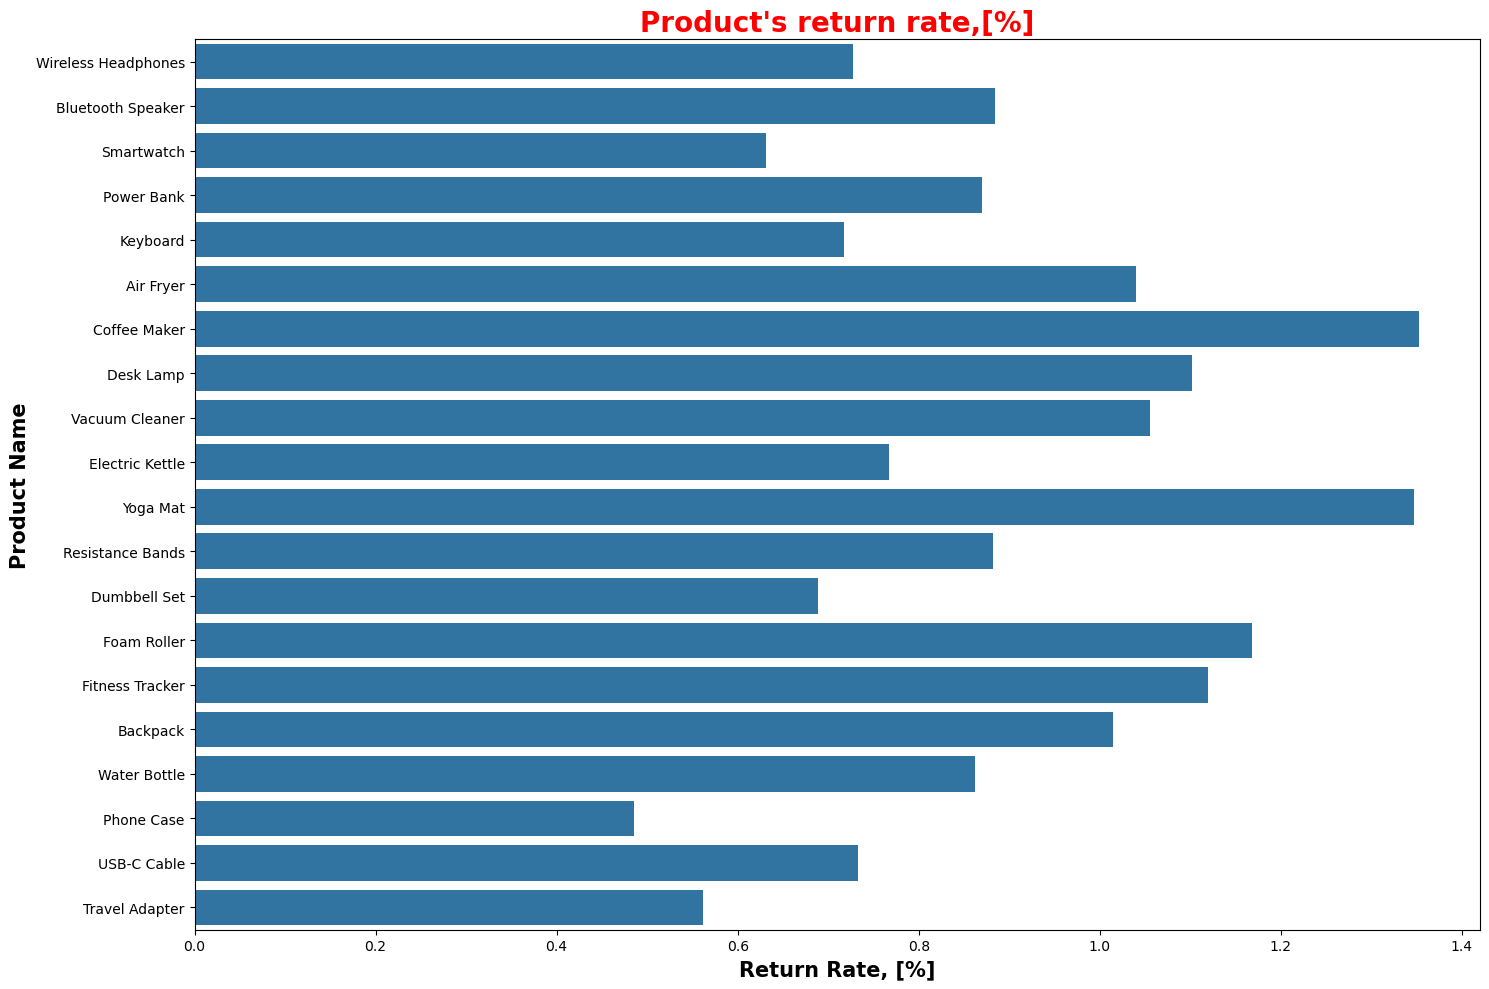

In [368]:
# Part D -- visualize the return rates by product, category, and store, then we can finish this task with a short business interpretation.
plt.figure(figsize=(15,10))
sns.barplot(return_rate,x ='return_rate',y='product_name')
plt.ylabel("Product Name",fontsize=15, fontweight= 'bold',)
plt.xlabel("Return Rate, [%]",fontdict={
    'fontsize': 15,
    'fontweight': 'bold'
})
plt.title("Product's return rate,[%]", 
          fontdict={
        'fontsize': 20,
        'fontweight': 'bold',
        'color': 'red',})
plt.tight_layout()
plt.show()

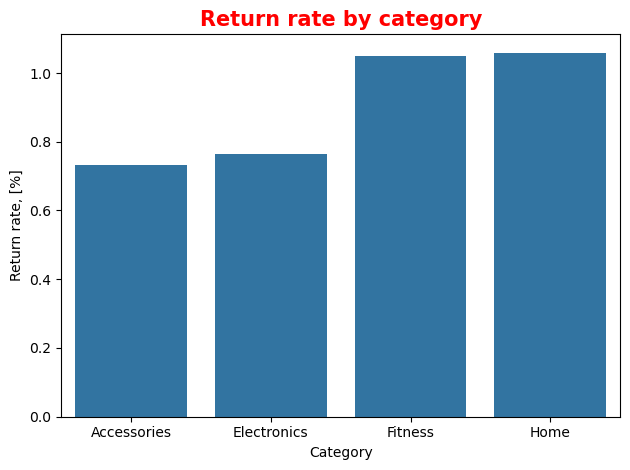

In [372]:
# Return Rate by category
sns.barplot(data=df_category_returned, x='category', y='return_rate')
plt.xlabel("Category")
plt.ylabel("Return rate, [%]")
plt.title("Return rate by category", fontdict={
    'fontsize': 15,
    'fontweight': "bold",
    'color': 'red'
})
plt.tight_layout()
plt.show()

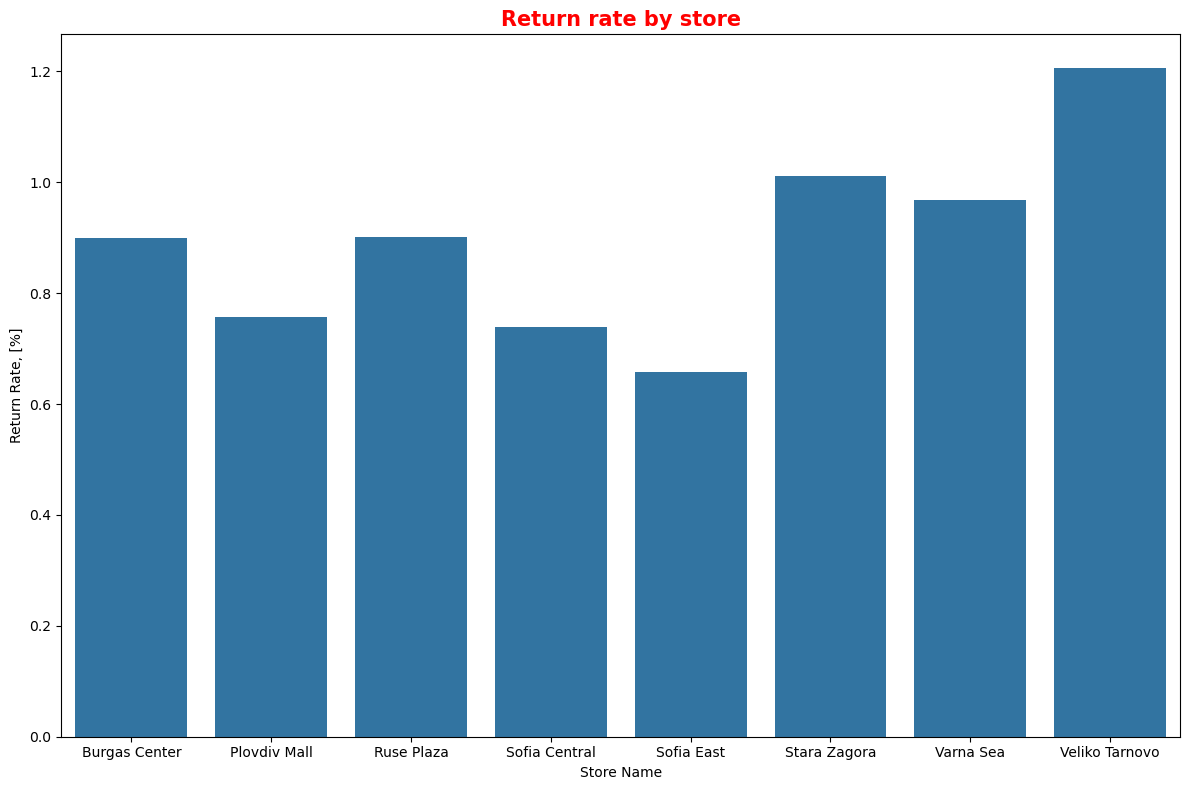

In [377]:
# Return Rate by store
plt.figure(figsize=(12,8))
sns.barplot(df_return_rate_by_store,x='store_name',y='return_rate')
plt.xlabel("Store Name")
plt.ylabel("Return Rate, [%]")
plt.title("Return rate by store", fontdict={
    'fontsize': 15,
    'fontweight': "bold",
    'color': 'red'
})
plt.tight_layout()
plt.show()

Answer on those questions:

1. Are the product return rates relatively similar, or are there obvious outliers?
2. Is the difference between categories large or small?
3. Are any stores clearly separated from the others?
4. Based on everything from Task 7, where would you investigate first: specific products, a category, or a store? Why?

In [384]:
print("Product return rate is relatively similiar with exception on Coffe Maker and Yoga Mat.")
print("The difference between categories noticeably differnt.")
print("The Store 'Veliko Turnovo' is separated from others.")
print("Coffee Maker and Yoga Mat have noticeably higher return rates than most other products. Veliko Tarnovo appears to have the highest store return rate.\
 Fitness and Home also show relatively higher return rates than the other categories.\
These areas should be investigated first because their return rates stand out from the rest.")

Product return rate is relatively similiar with exception on Coffe Maker and Yoga Mat.
The difference between categories noticeably differnt.
The Store 'Veliko Turnovo' is separated from others.
Coffee Maker and Yoga Mat have noticeably higher return rates than most other products. Veliko Tarnovo appears to have the highest store return rate. Fitness and Home also show relatively higher return rates than the other categories.These areas should be investigated first because their return rates stand out from the rest.


# Task 8 — Diagnose Why Returns Are High

Now move from “where are returns high?” to “why are they high?”

Use:

df_returns_merged

and focus on the areas that stood out in Task 7:

- products: Coffee Maker, Yoga Mat
- store: Veliko Tarnovo
- categories: Fitness, Home

### Part A — Return reasons by product

For Coffee Maker and Yoga Mat:

- count returns by reason
- calculate percentage share of each reason within each product

Then answer:

1. What is the most common return reason for each product?
2. Are the dominant reasons the same or different?
3. Does either product show one clearly dominant problem?

### Part B — Return condition by product

For the same two products, analyze condition:

- number of Resellable
- Opened
- Damaged

Then answer:

1. Which product has a larger share of damaged returns?
2. Which product has more returns that could potentially be resold?
3. What might that imply operationally?


#### Part C — Investigate Veliko Tarnovo

Filter returns for Veliko Tarnovo.

Calculate:

- total returns by reason
- total returns by condition
- top 5 returned products
- top categories by returned units

Then answer:

Does the store's high return rate appear to come from one product/category, or is it spread across many products?

### Part D — Compare Home vs Fitness

For Home and Fitness, calculate return-reason percentages.

Compare:

- defective
- changed mind
- wrong item
- not as expected
- damaged packaging

Then answer:

Do the two categories appear to have the same type of return problem?

Part E — Business interpretation

Write a short conclusion answering:

Based on Task 8, what should the business investigate first?

Do not jump to statistical testing yet. First determine whether the higher return rates have a clear business pattern.

In [457]:
# Part A 
coffee_maker_returns = df_returns_merged.loc[df_returns_merged['product_name']== 'Coffee Maker']['reason'].value_counts()
yoga_mat_returns = df_returns_merged.loc[df_returns_merged['product_name']== 'Yoga Mat']['reason'].value_counts()
coffee_yoga_merged = pd.merge(left=coffee_maker_returns,on='reason',right=yoga_mat_returns,how='outer').fillna(0)
coffee_yoga_merged.columns=['coffee_maker_counts', 'yoga_mat_counts']
coffee_yoga_merged['coffe_maker_returns_pct']=coffee_yoga_merged.coffee_maker_counts/coffee_yoga_merged.coffee_maker_counts.sum()*100
coffee_yoga_merged['yoga_mat_returns_pct']=(coffee_yoga_merged.yoga_mat_counts/coffee_yoga_merged.yoga_mat_counts.sum()*100).round(2)
print("Common return reason for Coffee maker and yoga mat is Wrong item.")
print("The dominant reason between both products is same. Wrong items around 30%.")
print("There is no clearly dominant problem.")




Common return reason for Coffee maker and yoga mat is Wrong item.
The dominant reason between both products is same. Wrong items around 30%.
There is no clearly dominant problem.


In [460]:
coffe_maker_condition_returns = df_returns_merged.loc[(df_returns_merged.product_name=='Coffee Maker')]['condition'].value_counts()
yoga_mat_condition_returns = df_returns_merged.loc[(df_returns_merged.product_name=='Yoga Mat')]['condition'].value_counts()
products_condition_returns = pd.merge(left=coffe_maker_condition_returns, on='condition', right=yoga_mat_condition_returns, how='outer').fillna(0)
products_condition_returns.columns=(['coffe_maker_condition_returns_counts', 'yoga_mat_condition_returns_counts'])
products_condition_returns['coffe_maker_returns_rate'] = products_condition_returns.coffe_maker_condition_returns_counts/products_condition_returns.coffe_maker_condition_returns_counts.sum()*100
products_condition_returns['yoga_mat_returns_rate'] = (products_condition_returns.yoga_mat_condition_returns_counts/products_condition_returns.yoga_mat_condition_returns_counts.sum()*100).round(2)
products_condition_returns

print("Yoga Mat has the higher damaged-return share: 58.82% vs 56.25%.")
print("oga Mat also has the higher resellable share: 29.41% vs 25.00%.")
print("A higher damaged share may imply larger financial loss, because damaged items may be harder or impossible to resell.")


Yoga Mat has a 58.82% damaged-return share, which is high.
Both products have more returns than potentially resold.
A higher damaged share may imply larger financial loss, because damaged items may be harder or impossible to resell.
